# kac_zwanzig quick start

Spectral density → kernel → exact C(t), dC/dt → one trajectory with its random force → sampled C(t) with error bars → recovering the memory kernel.

Equation numbers refer to the README. Run from the `examples/` directory.

In [1]:
import pathlib
import sys


import matplotlib.pyplot as plt
import numpy as np

import kac_zwanzig as kz

HERE = pathlib.Path('.').resolve()
sys.path.insert(0, str(HERE))
from naive_inversion import trapezoid_inversion  # noqa: E402

## 1. Spectral density and its discretization (eqs. 3, 10)

In [2]:
bath = kz.ohmic(eta=1.0, omega_c=1.0, N=2000)             # J(w) = eta w exp(-w/omega_c), midpoint-uniform grid
print(bath.describe())
w = np.linspace(0.01, 8, 400)
J_continuum = bath.J(w)
w_hist, J_hist = bath.spectral_density_histogram(bins=40)

# Any other J works too (numerical quantiles):
J_super = lambda x: 0.5 * x ** 3 * np.exp(-x)
bath_super = kz.Bath.from_spectral_density(J_super, N=1000, grid="uniform", omega_max=30, name="super-Ohmic")
print(bath_super.describe())

ohmic bath, N=2000, K0=0.636616, omega in [0.00625, 25]  (eta=1.0, omega_c=1.0, N=2000, grid=uniform, omega_max=25.0, midpoint=True)
super-Ohmic bath, N=1000, K0=0.63662, omega in [0.015, 30]  (N=1000, grid=uniform, omega_max=30, n_quad=200000)


## 2. Kernel (eq. 2)

In [3]:
t = np.arange(0, 20 + 1e-9, 0.1)
K_N = bath.kernel(t)                                       # exact finite-bath kernel
K_inf = bath.kernel_continuum(t)                           # continuum Lorentzian
print(f"max |K_N - K_inf| over t <= 20: {np.abs(K_N - K_inf).max():.1e}")

max |K_N - K_inf| over t <= 20: 4.2e-06


## 3. Exact correlation function, derivative and memory kernel (eqs. 5, 7)

In [4]:
s = kz.System(bath, M=1.0, kT=1.0)                         # free particle
C, Cdot = s.vacf(t), s.vacf_dot(t)
Gamma = s.memory_kernel(t)                                 # dC/dt = -int_0^t Gamma(t-s) C(s) ds; = K_N/M here

## 4. One exact trajectory with its random force, and the GLE check (eqs. 4, 8)

In [5]:
traj = s.trajectory(t, n_traj=1, seed=0, random_force=True)
v, a, q, F = traj.v[0], traj.a[0], traj.q[0], traj.F[0]
fine = s.trajectory(np.arange(0, 6, 0.002), n_traj=1, seed=0, random_force=True)     # same seed, finer grid
res = kz.gle_residual(s, fine)
print(f"GLE residual  M dv/dt + int K v - F  on a dt = 0.002 grid: max {np.abs(res).max():.1e} "
      f"(forces are O({np.abs(fine.F).max():.1f}))")

GLE residual  M dv/dt + int K v - F  on a dt = 0.002 grid: max 3.5e-07 (forces are O(1.9))


## 5. Sampled C(t) from n trajectories, with error bars (eq. 9)

In [6]:
n = 100_000
est = s.sampled_vacf(t, n_traj=n, seed=1)                  # sample normalization: est.C[0] == 1; 50 groups
sigma = np.sqrt(kz.predicted_variance(C, n, "sample"))     # eq. (9)
boot = est.bootstrap(n_boot=1000, seed=2)                  # resample the groups of trajectories
lo, hi = boot.band("C", level=0.95)
print(f"sampled C, {n} trajectories: RMS(C_hat - C) = {np.sqrt(((est.C - C) ** 2).mean()):.2e}, "
      f"predicted {np.sqrt((sigma ** 2).mean()):.2e}, bootstrap std (median over t) {np.median(boot.std()):.2e}  "
      f"(one realization of time-correlated noise: agreement within tens of percent is expected)")

sampled C, 100000 trajectories: RMS(C_hat - C) = 3.11e-03, predicted 3.06e-03, bootstrap std (median over t) 2.88e-03  (one realization of time-correlated noise: agreement within tens of percent is expected)


## 6. Recover the memory kernel from the sampled data (eq. 5)

In [7]:
data = s.inversion_data(t, est, derivative="acc")          # data.C, data.Cdot, data.dt; answer: data.memory_kernel
G_solved = trapezoid_inversion(data.C, data.Cdot, data.dt, data.memory_kernel_0)
G_reps = np.array([trapezoid_inversion(boot.C[b], boot.Cdot_acc[b], data.dt, data.memory_kernel_0)
                   for b in range(200)])
G_lo, G_hi = np.percentile(G_reps, [2.5, 97.5], axis=0)
covered = np.mean((G_lo <= Gamma) & (Gamma <= G_hi))
print(f"trapezoid inversion of the sampled data: max |Gamma_solved - Gamma| = {data.residual(G_solved):.2e}; "
      f"the bootstrap 95% band contains the exact kernel at {100 * covered:.0f}% of the points  "
      f"(the first-kind inversion amplifies the {sigma.max():.0e} noise in C; how much, as a function of dt, "
      f"the solver and the derivative estimator, is what this package lets you study)")

trapezoid inversion of the sampled data: max |Gamma_solved - Gamma| = 1.21e-02; the bootstrap 95% band contains the exact kernel at 100% of the points  (the first-kind inversion amplifies the 3e-03 noise in C; how much, as a function of dt, the solver and the derivative estimator, is what this package lets you study)


## Figure

wrote /Users/williampfalzgraff/Desktop/Research/kac-zwanzig/examples/output/quickstart.png


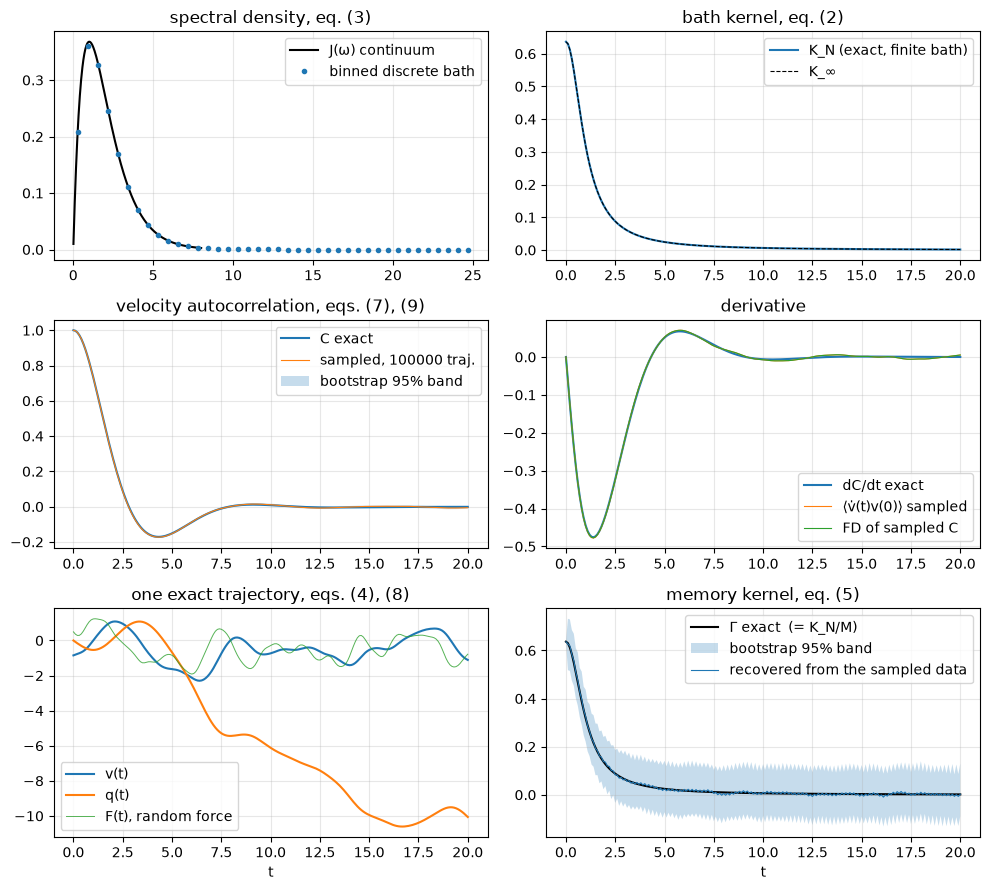

In [8]:
fig, ax = plt.subplots(3, 2, figsize=(10, 9))
ax[0, 0].plot(w, J_continuum, "k", label="J(ω) continuum")
ax[0, 0].plot(w_hist, J_hist, ".", label="binned discrete bath")
ax[0, 0].set_title("spectral density, eq. (3)")
ax[0, 0].legend()
ax[0, 1].plot(t, K_N, label="K_N (exact, finite bath)")
ax[0, 1].plot(t, K_inf, "k--", lw=0.8, label="K_∞")
ax[0, 1].set_title("bath kernel, eq. (2)")
ax[0, 1].legend()
ax[1, 0].plot(t, C, label="C exact")
ax[1, 0].plot(t, est.C, lw=0.8, label=f"sampled, {n} traj.")
ax[1, 0].fill_between(t, lo, hi, alpha=0.25, label="bootstrap 95% band")
ax[1, 0].set_title("velocity autocorrelation, eqs. (7), (9)")
ax[1, 0].legend()
ax[1, 1].plot(t, Cdot, label="dC/dt exact")
ax[1, 1].plot(t, est.Cdot_acc, lw=0.8, label="⟨v̇(t)v(0)⟩ sampled")
ax[1, 1].plot(t, kz.finite_difference(est.C, 0.1, order=2), lw=0.8, label="FD of sampled C")
ax[1, 1].set_title("derivative")
ax[1, 1].legend()
ax[2, 0].plot(t, v, label="v(t)")
ax[2, 0].plot(t, q, label="q(t)")
ax[2, 0].plot(t, F, lw=0.7, alpha=0.8, label="F(t), random force")
ax[2, 0].set_title("one exact trajectory, eqs. (4), (8)")
ax[2, 0].legend()
ax[2, 0].set_xlabel("t")
ax[2, 1].plot(t, Gamma, "k", label="Γ exact  (= K_N/M)")
ax[2, 1].fill_between(t, G_lo, G_hi, alpha=0.25, label="bootstrap 95% band")
ax[2, 1].plot(t, G_solved, lw=0.8, label="recovered from the sampled data")
ax[2, 1].set_title("memory kernel, eq. (5)")
ax[2, 1].legend()
ax[2, 1].set_xlabel("t")
for a_ in ax.ravel():
    a_.grid(alpha=0.3)
fig.tight_layout()
out = HERE / "output"
out.mkdir(exist_ok=True)
fig.savefig(out / "quickstart.png", dpi=130)
print("wrote", out / "quickstart.png")